In [1]:
import sys

sys.path.insert(0, '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib')
print(sys.path)

['/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/mylib', '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/notebook/playground', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python312.zip', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/lib-dynload', '', '/home/amunif/.local/lib/python3.12/site-packages', '/uwahpc/centos8/python/Anaconda3/2024.06/lib/python3.12/site-packages']


In [2]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util

In [3]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [4]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 100_000
BATCH_SIZE = 32
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

hidden1_size=64
hidden2_size=32

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-autoencoder-cnn-{hidden1_size}-{hidden2_size}-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'model', f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'train', f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'test', f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "train", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, "test", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'roc', f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'autoencoder', MODE, 'img', 'cm', f"{PREFIX}-cm-{SUFFIX}.png")

# INPUT_SIZE = 256

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/autoencoder/all_features/model/dol1l2-autoencoder-cnn-64-32-0.2-checkpoint-100000-100-32-0.005-0.001.pt


# Layer 1: Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3))

Input: (1, 5, 4000)
Kernel: (5, 10)
Stride: (1, 4)
Padding: (0, 3)

Output height = (5 - 5 + 2*0)/1 + 1 = 1
Output width = (4000 - 10 + 2*3)/4 + 1 = 999
After Layer 1: (16, 1, 999)

# Layer 2: Conv2d(16, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))

Input: (16, 1, 999)
Kernel: (1, 10)
Stride: (1, 4)
Padding: (0, 3)

Output height = (1 - 1 + 2*0)/1 + 1 = 1
Output width = (999 - 10 + 2*3)/4 + 1 = 249
After Layer 2: (32, 1, 249)

# Layer 3: Conv2d(32, 64, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))

Input: (32, 1, 249)
Kernel: (1, 10)
Stride: (1, 4)
Padding: (0, 3)

Output height = (1 - 1 + 2*0)/1 + 1 = 1
Output width = (249 - 10 + 2*3)/4 + 1 = 62
After Layer 3: (64, 1, 62)

# Layer 4: Conv2d(64, latent_dim, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2))

Input: (64, 1, 62)
Kernel: (1, 5)
Stride: (1, 2)
Padding: (0, 2)

Output height = (1 - 1 + 20)/1 + 1 = 1
Output width = (62 - 5 + 22)/2 + 1 = 31
Final output: (latent_dim, 1, 31)

In [5]:
class CNNAutoEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(CNNAutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3)),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=(1, 10), stride = (1, 4), padding=(0,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=(1, 10), stride = (1, 4), padding=(0,3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, latent_dim, kernel_size=(1, 5), stride = (1, 2), padding=(0,2)),
            # nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2), output_padding=(0, 1)),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0)),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3), output_padding=(0, 0)),
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

In [6]:
class HepG2DatasetCNNAutoEncoder(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 15]
        feature_2 = self.features[r2, 15]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 12]
        val_2 = self.features[r2, 12]

        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [7]:
# Load dataset
gene_pl = pl.read_parquet(os.path.join(DATASET_DIR, 'gene_w_label_value_1.parquet'))
gene_pl

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0


In [8]:
# Stack each histone into 5x4000 elements
marker_list = ['H3K4me3', 'H3K9ac', 'H3K9me3', 'H3K27ac', 'H3K27me3']

gene_features = gene_pl.with_columns(
    pl.struct(marker_list).map_elements(
        lambda x: [x[col_name] for col_name in marker_list],
        return_dtype = pl.List(pl.List(pl.Float64))
    ).alias("histone")
)

gene_features

gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone
str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[list[f64]]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [9]:
# Generate the dataframe index
gene_features = gene_features.with_row_index("index")
gene_features

index,gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone
u32,str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[list[f64]]
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [10]:
X = gene_features.select(pl.col('histone')).to_series().to_list()

In [11]:
X = np.array(X)

In [12]:
y = gene_features.select(pl.col('label')).to_series().to_list()

In [13]:
y = np.array(y)

In [14]:
# Split data to train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(X_train.shape)
print(X_val.shape)

(17723, 5, 4000)
(4431, 5, 4000)


In [16]:
# Convert to Tensor
X_train_tensor = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val_tensor = torch.from_numpy(X_val).float().unsqueeze(1).to(device)

print(X_train_tensor.shape)
print(X_val_tensor.shape)

torch.Size([17723, 1, 5, 4000])
torch.Size([4431, 1, 5, 4000])


In [17]:
# Initialize the model
latent_dim = 64  # Size of the bottleneck layer
ae_model = CNNAutoEncoder(latent_dim=latent_dim).to(device)
print(ae_model)

CNNAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 10), stride=(1, 4), padding=(0, 3))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2))
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(1, 5), stride=(1, 2), padding=(0, 2), output_padding=(0, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(64, 32, kernel_size=(1, 10), stride=(1, 4), padding=(0, 3), output_padding=(

In [18]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters())

In [19]:
# Training loop
n_epochs = 200
batch_size = 32
train_losses = []
val_losses = []

In [20]:
for epoch in range(n_epochs):
    ae_model.train()
    train_loss = 0
    
    # Train in batches
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train_tensor[i:i + batch_size]
        
        # Forward pass
        outputs = ae_model(batch_X)
        loss = criterion(outputs, batch_X)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Evaluate on test set
    ae_model.eval()
    with torch.no_grad():
        val_outputs = ae_model(X_val_tensor)
        val_loss = criterion(val_outputs, X_val_tensor)
    
    train_losses.append(train_loss / (len(X_train) / batch_size))
    val_losses.append(val_loss.item())
    
    # if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

Epoch [1/200], Train Loss: 0.0297, Val Loss: 0.0029
Epoch [2/200], Train Loss: 0.0017, Val Loss: 0.0010
Epoch [3/200], Train Loss: 0.0008, Val Loss: 0.0006
Epoch [4/200], Train Loss: 0.0005, Val Loss: 0.0005
Epoch [5/200], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [6/200], Train Loss: 0.0003, Val Loss: 0.0003
Epoch [7/200], Train Loss: 0.0003, Val Loss: 0.0002
Epoch [8/200], Train Loss: 0.0002, Val Loss: 0.0002
Epoch [9/200], Train Loss: 0.0002, Val Loss: 0.0002
Epoch [10/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [11/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [12/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [13/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [14/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [15/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [16/200], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [17/200], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [18/200], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [19/200], Train Loss: 0.0000, Val Loss: 0.0000
Ep

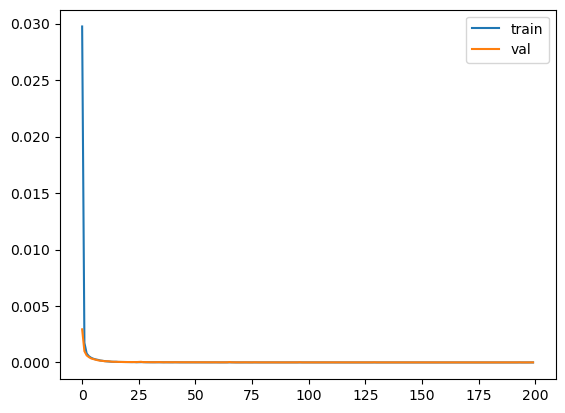

In [21]:
# Plot training results
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.show()

In [22]:
flatten = nn.Flatten()

In [23]:
X.shape

(22154, 5, 4000)

In [24]:
X_tensor = torch.from_numpy(X).float().unsqueeze(1).to(device)

ae_model.eval()
with torch.no_grad():
    X_encoded = ae_model.encode(X_tensor)

In [25]:
X_encoded.shape

torch.Size([22154, 64, 1, 31])

In [26]:
X_flatten = flatten(X_encoded)

In [27]:
X_encoded_np = X_flatten.cpu().detach().numpy()
print(type(X_encoded_np))
print(X_encoded_np.shape)

<class 'numpy.ndarray'>
(22154, 1984)


In [28]:
X_encoded_pl = pl.from_numpy(X_encoded_np, schema=["all_features_encoded"])

In [29]:
X_encoded_pl

all_features_encoded
"array[f32, 1984]"
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"
…
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"
"[2.41958, 3.386123, … -2.049751]"


In [30]:
# Concatenate the new column horizontally
af_encoded = pl.concat([gene_features, X_encoded_pl], how='horizontal')

In [31]:
af_encoded

index,gene_id,H3K4me3,H3K4me3_count,H3K9ac,H3K9ac_count,H3K9me3,H3K9me3_count,H3K27ac,H3K27ac_count,H3K27me3,H3K27me3_count,value_1,label,histone,all_features_encoded
u32,str,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,list[f64],i64,f64,i32,list[list[f64]],"array[f32, 1984]"
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0888452,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,4.04743,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",6,"[0.0, 0.0, … 0.0]",3,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",2,"[0.0, 0.0, … 0.0]",0,26.7934,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,"[0.0, 0.0, … 0.0]",0,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[2.41958, 3.386123, … -2.049751]"


In [32]:
af_encoded_np = af_encoded.to_numpy()

In [33]:
af_encoded_np.shape

(22154, 16)

In [34]:
# Split train, test, validation by index
data_indices = np.arange(len(af_encoded_np))
print(data_indices)

[    0     1     2 ... 22151 22152 22153]


In [35]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [36]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [37]:
print(train_idx)
print(val_idx)
print(test_idx)

[12829 12333  8225 ...  5390   860 15795]
[13202 15153  3113 ...  1158  6603 15289]
[17261  8344  1396 ...  7985   482 16493]


In [38]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17723
Test indices: 2216
Validation indices: 2215


In [39]:
# Define the dataset
train_dataset = HepG2DatasetCNNAutoEncoder(int(0.8 * NUM_ITEMS), af_encoded_np, train_idx)
val_dataset = HepG2DatasetCNNAutoEncoder(int(0.1 * NUM_ITEMS), af_encoded_np, val_idx)
test_dataset = HepG2DatasetCNNAutoEncoder(int(0.1 * NUM_ITEMS), af_encoded_np, test_idx)

In [40]:
print(train_dataset.__len__())

80000


In [41]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [42]:
# Initialize the model
INPUT_SIZE = 3968

model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, hidden1_size=512, hidden2_size=256, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [43]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=3968, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [44]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [45]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    START_EPOCH = 0

In [46]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:

        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # # Adjust learning rate
    # scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

Epoch [1/100] - [TRAIN] Loss: 0.6550, Accuracy: 68.49%, AUC: 0.68 [VAL] Loss: 0.6369, Accuracy: 69.62%, Precision: 0.70, Recall: 0.63, F1-Score: 0.66, AUC: 0.69
Epoch [2/100] - [TRAIN] Loss: 0.6304, Accuracy: 70.39%, AUC: 0.70 [VAL] Loss: 0.6356, Accuracy: 69.61%, Precision: 0.71, Recall: 0.61, F1-Score: 0.66, AUC: 0.69
Epoch [3/100] - [TRAIN] Loss: 0.6227, Accuracy: 70.75%, AUC: 0.70 [VAL] Loss: 0.6279, Accuracy: 69.90%, Precision: 0.70, Recall: 0.64, F1-Score: 0.67, AUC: 0.70
Epoch [4/100] - [TRAIN] Loss: 0.6132, Accuracy: 71.42%, AUC: 0.71 [VAL] Loss: 0.6226, Accuracy: 70.26%, Precision: 0.69, Recall: 0.65, F1-Score: 0.67, AUC: 0.70
Epoch [5/100] - [TRAIN] Loss: 0.6105, Accuracy: 71.14%, AUC: 0.71 [VAL] Loss: 0.6341, Accuracy: 69.45%, Precision: 0.68, Recall: 0.67, F1-Score: 0.67, AUC: 0.69
Epoch [6/100] - [TRAIN] Loss: 0.6042, Accuracy: 71.90%, AUC: 0.72 [VAL] Loss: 0.6239, Accuracy: 70.48%, Precision: 0.70, Recall: 0.63, F1-Score: 0.66, AUC: 0.70
Epoch [7/100] - [TRAIN] Loss: 0.60

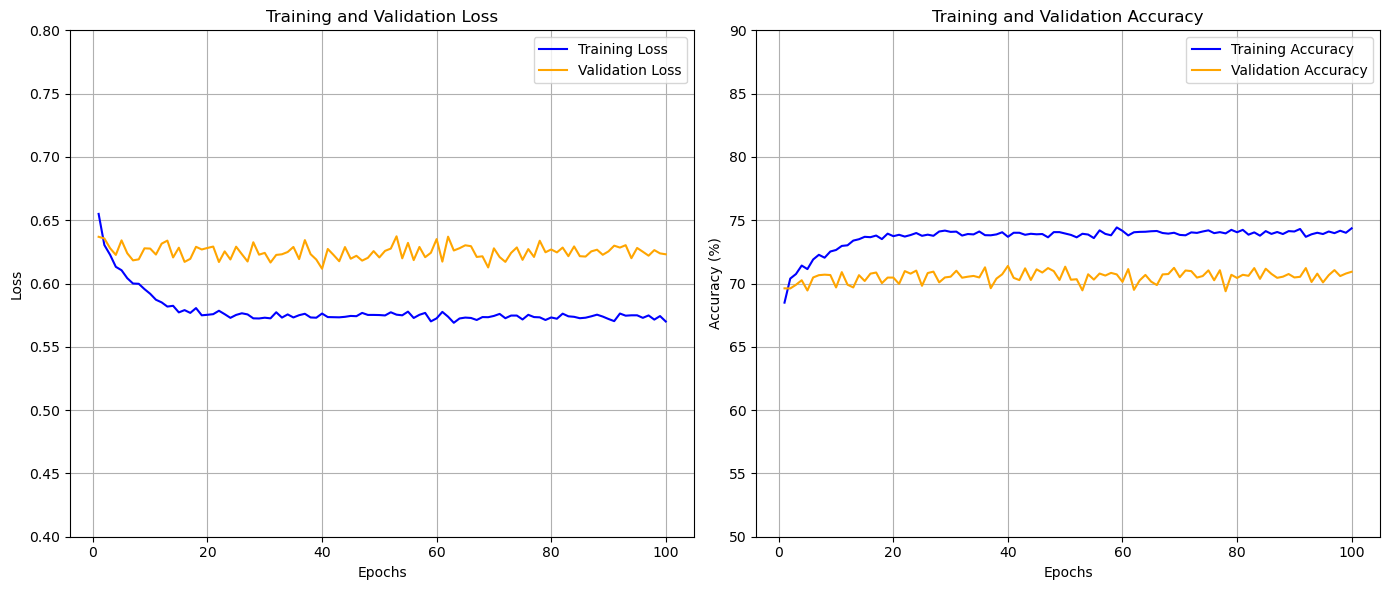

In [47]:
# Plot metrics
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [48]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [49]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [50]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 70.74 %
AUC Score on test set: 0.70
Precision: 0.7162
Recall: 0.6389
F1-Score: 0.6753

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      5237
           1       0.72      0.64      0.68      4763

    accuracy                           0.71     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.71      0.71     10000


Confusion Matrix:
[[4031 1206]
 [1720 3043]]



In [51]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [52]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [53]:
# Test output
test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

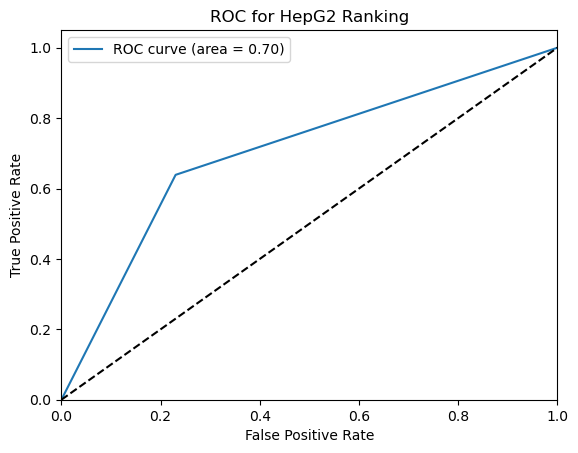

In [54]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

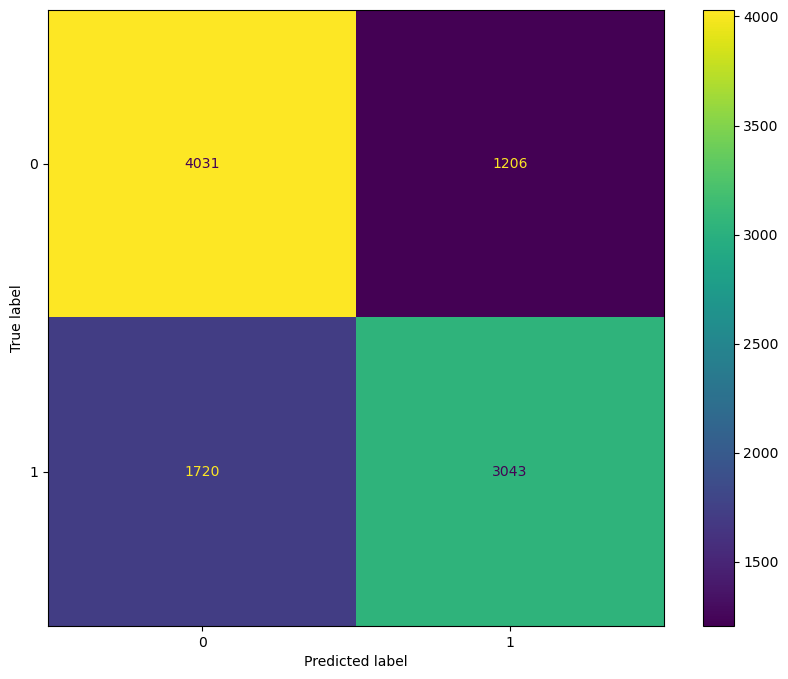

In [55]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)